## RAG in LangGraph


First import all the ncessary libraries

In [3]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START 
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

True

Define the model

In [4]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

Define the PDF loader and load the book.

Here Each page will be a document.

In [9]:
loader = PyPDFLoader("Data/Intro_to_ML.pdf")
docs  = loader.load()
len(docs)

392

Now, lets split the document in to chunks.

In [10]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap = 200)
chunks = splitter.split_documents(docs)
len(chunks)

973

Now, lets convert those chunks to embeddings


In [11]:
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')


Now, lets store, these embeddings in a vector store.

In [14]:
vector_store= FAISS.from_documents(chunks, embeddings)

Now, lets make this vector store in to a retriever , so that it not only stores, but also acts as a search engine which goes to the DB and then gets the matching chunk to the user query etc.

Here, while defining the retriever, we define the type of search and how many top 'n' results we want it to get.

In [15]:
retriever = vector_store.as_retriever(search_type= 'similarity',search_kwargs={'k':4})

Now, we make this retriever as a tool for langgraph

In [16]:
@tool
def rag_tool(query):
    """ 
    Retrieve relvent information from the pdf document.
    Use this tool when the user asks factual / conceptual questions.
    that might be ansered from the stored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata 
    }

Now, make the tools list and give the model the tools access

In [17]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

Now, lets create the graph

1. First define the state
2. Define the nodes
3. Define the edges
4. Compile the graph

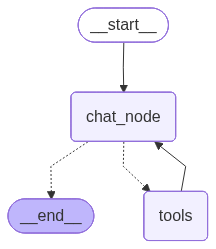

In [21]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

tool_node = ToolNode(tools)

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

chatbot

Lets invoke the chatbot which we made above.

In [22]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(content="Using the pdf notes, explain how to find the ideal value of K in K-Nearest neighbours")
        ]
     }
)

print(result['messages'][-1].content)

To find the ideal value of \( K \) in the K-Nearest Neighbors (K-NN) algorithm, you can follow several general guidelines based on the context provided in the notes:

1. **Understanding the Role of \( K \)**: 
    - \( K \) represents the number of nearest neighbors considered for making predictions. A smaller value of \( K \) (e.g., 1) means the prediction is heavily influenced by the closest data point, potentially leading to noisy predictions. Conversely, a larger \( K \) averages the predictions across more neighbors, resulting in smoother but potentially less precise predictions.

2. **Testing Different Values of \( K \)**:
    - It is advisable to experiment with various values of \( K \) (such as 1, 3, 5, etc.) to observe how it affects the model's performance. Observing the predictions as \( K \) varies can illuminate the trade-off between bias and variance in the model.

3. **Validation Techniques**:
    - Use techniques such as cross-validation to determine which value of \( 

In [23]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(content="Using the pdf notes, explain how to split a node in decision tree")
        ]
     }
)

print(result['messages'][-1].content)

To split a node in a decision tree, the process involves finding the most informative test that separates the data points based on the target variable. Here is a breakdown of the steps:

1. **Identify Possible Tests**:
    - The algorithm evaluates all possible tests that can be performed on the available features. A test typically checks if a feature value is less than or equal to a certain threshold.

2. **Determine the Best Split**:
    - For each test, the algorithm calculates how well it separates the classes in the dataset. This is achieved by measuring the information gain or other metrics that indicate how well the split distinguishes between the classes.

3. **Perform the Split**:
    - Once the best test is identified (e.g., splitting the dataset based on a feature value), the dataset is divided into two subsets:
        - One subset contains the data points that meet the condition of the test (e.g., `x[1] <= 0.0596`).
        - The other subset contains the points that do no